# Exploratory Data Analysis on the Titanic Dataset

## 1. Dataset Description 
The Titanic dataset represents the passengers details from the Titanic disaster, including whether they survived the disaster. The variables includes:

- **PassngerId**: Unique identifier for each passnger
- **Survived**: Survival status (0 = No, 1 = Yes)
- **Pclass**: Ticket class (1st, 2nd, 3rd)
- **Name**: Passenger's full name
- **Sex**: Gender
- **Age**: Age in years
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Ticket**: Ticket number
- **Fare**: Ticket fare paid
- **Cabin**: Cabin number (often missing)
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

## 2. Data Cleaning

In this section, we describe the steps taken to clean the Titanic dataset before analysis:

- **Removed duplicates**: Checked for duplicate passenger records and dropped them if found.
- **Converted data types**: Ensured numerical columns (Age, Fare) are stored as numbers, and categorical columns (Sex, Embarked) are stored as categories.
- **Handled inconsistent values**: Verified that categorical variables (e.g., Embarked) only contain valid codes(C, Q, S).
- **Dropped irrelevant columns**: Removed columns not useful for analysis (e.g., Ticket number if not needed).



In [1]:
import pandas as pd 
df = pd.read_csv("Titanic.csv")

df.drop_duplicates(inplace=True)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df.drop(columns=['Ticket'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Fare         891 non-null    float64 
 9   Cabin        204 non-null    str     
 10  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), str(2)
memory usage: 64.6 KB


## 3. Handled Missing Data 
In this section, we describe how missing values in the Titanic dataset were managed:

- **Age column**: Missing ages were imputed using the median age to preserve distribution.
- **Cabin column**: Dropped due to a high percentage of missing enteries.
- **Embarked column**: Filled missing values with thw most common port of embarkaation.


In [2]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.isnull().sum()

C:\Users\maano\AppData\Local\Temp\ipykernel_5848\865079651.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\maano\AppData\Local\Temp\ipykernel_5848\865079651.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64

## 4. Data Stories and Visualisations

In this section, we highlight key findings supported by plots.

### 4.1 Survival by Gender

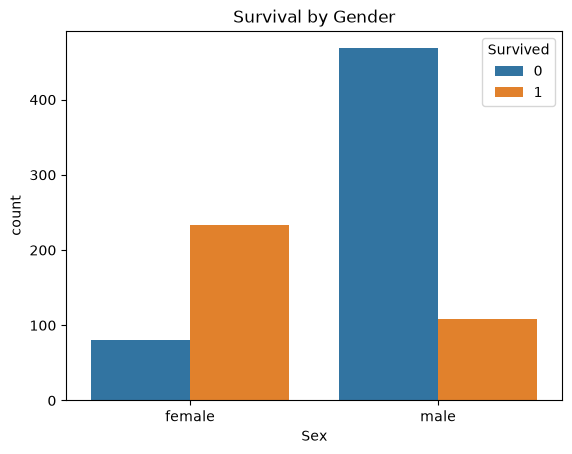

In [3]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

### 4.2 Survival by Class

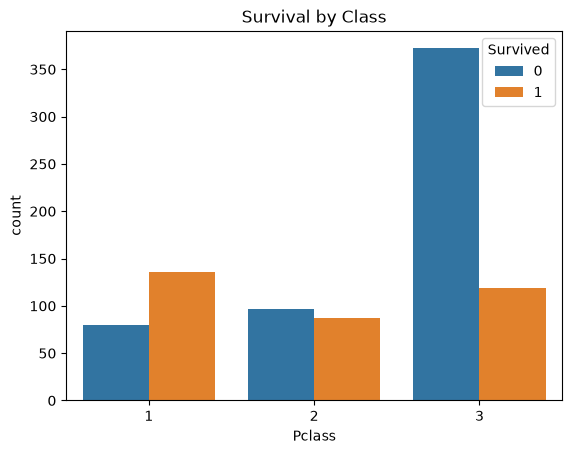

In [4]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Class")
plt.show()

### 4.3 Age Distribution

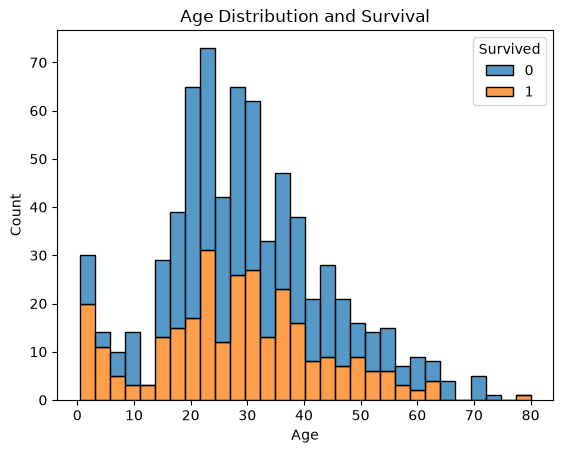

In [5]:
sns.histplot(data=df, x="Age", bins=30, hue="Survived", multiple="stack")
plt.title("Age Distribution and Survival")
plt.show()

### 4.4 Fare vs Age 

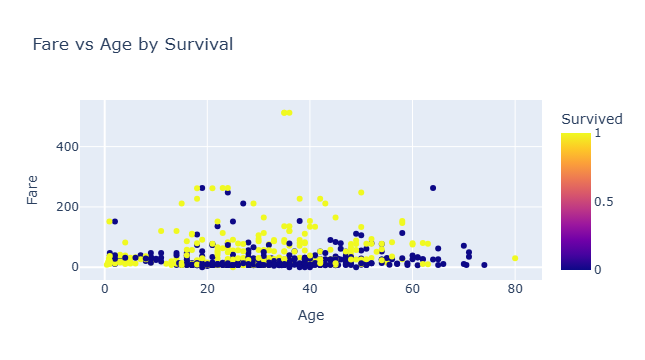

In [6]:
import plotly.express as px
fig = px.scatter(df, x="Age", y="Fare", color="Survived",
                 title="Fare vs Age by Survival")
fig.show()

## 5. Findings 

In this section, we present the main insights discovered from Titanic dataset and the visualisations above:

- **Survival by Gender**: Women had a significantly higher survival rate compared to men.
- **Survival by Class**: Passenger in 1st class were more likely to survive than those in 2nd or 3rd class.
- **Age Distribution**: Most passenger were between 20-40 years old, with survival rates varying across age groups.
- **Fare Analysis**: Higher fares were generally associated with higher survival chances, reflecting class differences.

**This report was written by**: Jufter Nditsheni Maano